In [1]:
import numpy as np
import cantera as ct

In [3]:
waffle = np.load(r'C:\GIT_Fork\ROMify\examples\1D_RDE\FOM_results\8000iteration_prim.npy')
ic_waffle = waffle[:-1,:]
np.save(r'C:\GIT_Fork\ROMify\examples\1D_RDE\IC_8000.npy',ic_waffle)

In [20]:
gas = ct.Solution('h2o2.yaml')
gas.set_equivalence_ratio(phi=1, fuel='H2', oxidizer='O2:1.0, Ar:7')
gas.TP = 3500,20*ct.one_atm
phi_Y = gas.Y
print(gas.Y)
print(gas.density)

[0.01277243 0.         0.         0.10136214 0.         0.
 0.         0.         0.88586543 0.        ]
2.1983227106095016


In [9]:

prim_state = np.load(r'C:\GIT_Fork\ROMify\examples\1D_RDE\Injection_Files\h2o2ar_phi_12_200ms_025atm_inject_prim_state.npy')
print(prim_state)

[[2.56470983e+00]
 [2.00000000e+02]
 [2.53312500e+04]
 [3.00000000e+02]
 [1.52878607e-02]
 [0.00000000e+00]
 [0.00000000e+00]
 [1.01103870e-01]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [8.83608269e-01]
 [0.00000000e+00]]


In [85]:
prim_state[4:,0] = phi_Y
np.save(r'C:\GIT_Fork\ROMify\examples\1D_RDE\Injection_Files\h2o2ar_phi_08_200ms_025atm_inject_prim_state.npy',prim_state)
print(prim_state)

[[2.56470983e+00]
 [2.00000000e+02]
 [2.53312500e+04]
 [3.00000000e+02]
 [1.02441107e-02]
 [0.00000000e+00]
 [0.00000000e+00]
 [1.01621730e-01]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [8.88134159e-01]
 [0.00000000e+00]]


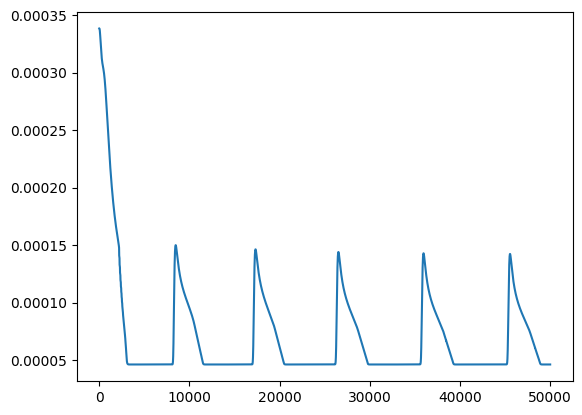

In [92]:
data_dir    = r'C:\GIT_Fork\ROMify\examples\1D_RDE\FOM_results3\cons_gathered.npy'
main_data   = np.load(data_dir)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(main_data[0,100,:],color='tab:blue')
plt.show()

In [93]:
import os
import numpy as np

data_dir    = r'C:\GIT_Fork\ROMify\examples\1D_RDE\FOM_results3\cons_gathered.npy'
pod_energy  = 99.999
cell_number = 200

main_data = np.load(data_dir)

training_data_cons = main_data[:,:,20000:]

# number of snapshot
num_snapshot = len(training_data_cons[0,0,:])

# reference profile
# q_ref = training_data_cons[:,:,0]
q_ref = np.mean(training_data_cons,axis=2)

# center data 
centered_data = training_data_cons - q_ref[:,:,np.newaxis]

# normalizing factors
l2_factors         = np.sqrt(np.sum(centered_data**2, axis=2))
norm_factor        = np.mean(l2_factors, axis=1)

# centered_normalized data
cen_norm_data = centered_data / norm_factor[:, np.newaxis, np.newaxis]

# data matrix
tall_thin_data = cen_norm_data.reshape(-1, num_snapshot)

# perform SVD
V, S, U = np.linalg.svd(tall_thin_data, full_matrices=False)

# POD residual energy check
square_sum_singular_values = np.sum(S**2)
cumulative_energy          = np.cumsum(S**2)
POD_res_energy             = (1 - (cumulative_energy / square_sum_singular_values)) * 100

POD_energy_limit = 100-pod_energy

truncation_indx = np.where(np.array(POD_res_energy) < POD_energy_limit)[0][0]

print(truncation_indx+1)

481


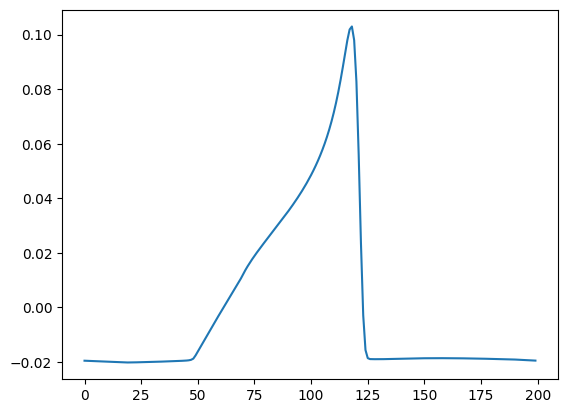

In [78]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(cen_norm_data[0,:,50],color='tab:blue')
plt.show()

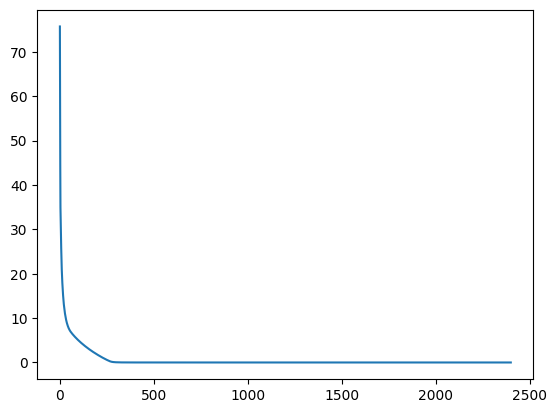

In [102]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(POD_res_energy,color='tab:blue')
# plt.xlim(0,200)
plt.show()

In [103]:
# finalize the basis
# basis = V[:,0:truncation_indx+1]
basis = V[:,0:190]

# wrap up and exit the function
denormalizor = np.repeat(norm_factor, cell_number)
normalizor   = 1/denormalizor

basis               = basis
q_ref               = q_ref.ravel()
norm                = normalizor
denorm              = denormalizor
qr0                 = basis.T @ tall_thin_data[:,0]

rom_basis_dir = r'C:\GIT_Fork\ROMify\examples\1D_RDE\pregenerated_basis'

np.save(os.path.join(rom_basis_dir,'basis.npy') , basis)
np.save(os.path.join(rom_basis_dir,'q_ref.npy') , q_ref)
np.save(os.path.join(rom_basis_dir,'norm.npy')  , norm)
np.save(os.path.join(rom_basis_dir,'denorm.npy'), denorm)
np.save(os.path.join(rom_basis_dir,'qr0.npy')   , qr0) 


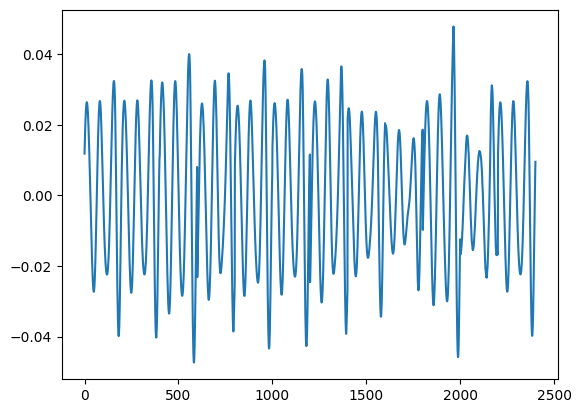

In [101]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(basis[:,4],color='tab:blue')
plt.show()

In [117]:
fom_cons = np.load(r'C:\GIT_Fork\ROMify\examples\1D_RDE\FOM_results3\cons_gathered.npy')

fom_cons_solver = np.reshape(fom_cons,(-1,49999))

fom_cons_cent = fom_cons_solver - q_ref[:,np.newaxis]

fom_cons_cent_norm = fom_cons_cent * norm[:,np.newaxis]

rom_cons_cent_norm = basis @ basis.T @ fom_cons_cent_norm

rom_cons_cent = rom_cons_cent_norm * denorm[:,np.newaxis]

rom_cons_solver = rom_cons_cent + q_ref[:,np.newaxis]

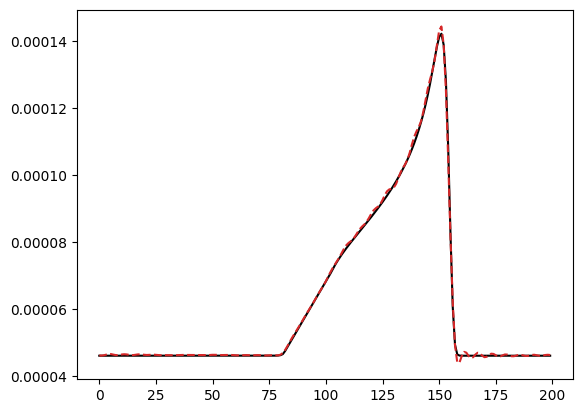

: 

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fom_cons_solver[0:200,48000],color='black'  ,ls='-' )
plt.plot(rom_cons_solver[0:200,48000],color='tab:red',ls='--')
plt.show()

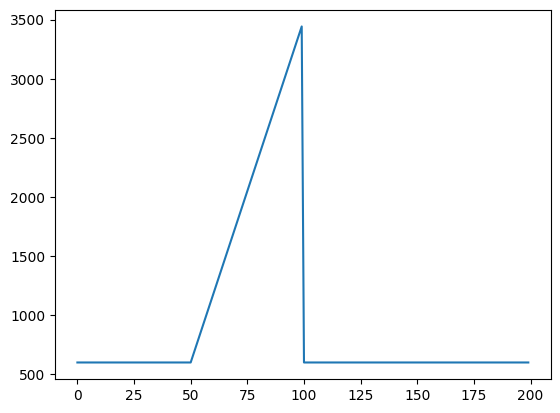

In [26]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

P_ratio = 20
T_ratio = 10


# indx_peak      = int(1400/2.5)
# indx_ramp_begin= int(500/2.5)
indx_peak      = int(100)
indx_ramp_begin= int(50)


indx_list = np.arange(indx_ramp_begin,indx_peak)


rho_flow = [2*1.2823549145222093]
u_flow   = [0.01]
P_flow   = [101325]
T_flow   = [2*300]
MF_flow  = np.array([0.11190674  , 0.,         0.,         0.10136214, 0.,         0.,
                                0.,         0.,         0.88586543,         0.,        ])

# MF_flow  = np.array([1,0])



# rho_peak = [3.136307624147092]
# rho_peak = [5.129419658088836]
# rho_peak = [6.4]
rho_peak = [2.1983227106095016]
u_peak   = [0.01]
# P_peak   = [7599375.0]
# P_peak   = [4053000.0]
# P_peak   = [1013250.0]
# P_peak   = [506625]
P_peak   = [101325*20]
T_peak   = [3500]
# MF_peak  = np.array([1,0])
MF_peak  = np.array([0.11190674  , 0.,         0.,         0.10136214, 0.,         0.,
                                0.,         0.,         0.88586543,         0.,        ])




q_flow  = np.concatenate((rho_flow,u_flow,P_flow,T_flow,MF_flow))
q_peak  = np.concatenate((rho_peak,u_peak,P_peak,T_peak,MF_peak))


x_knwon = np.array([indx_ramp_begin,indx_peak])
y_known = np.array([q_flow,q_peak]).T

x       = indx_list

f_interp = interp1d(x_knwon,y_known,kind='linear')
q_ramp   = f_interp(x)

q_prim_ic = np.zeros((14,200))+q_flow[:,np.newaxis]
q_prim_ic[:,indx_ramp_begin:indx_peak]=q_ramp
q_prim_ic[4:,0:indx_peak]=0


np.save(r'C:\GIT_Fork\ROMify\examples\1D_RDE\IC_test_ramp_PR_2_200.npy',q_prim_ic[:-1,:])

import matplotlib.pyplot as plt
plt.figure()
plt.plot(q_prim_ic[3,:],color='tab:blue')
# plt.plot(,color='tab:red')
plt.show()

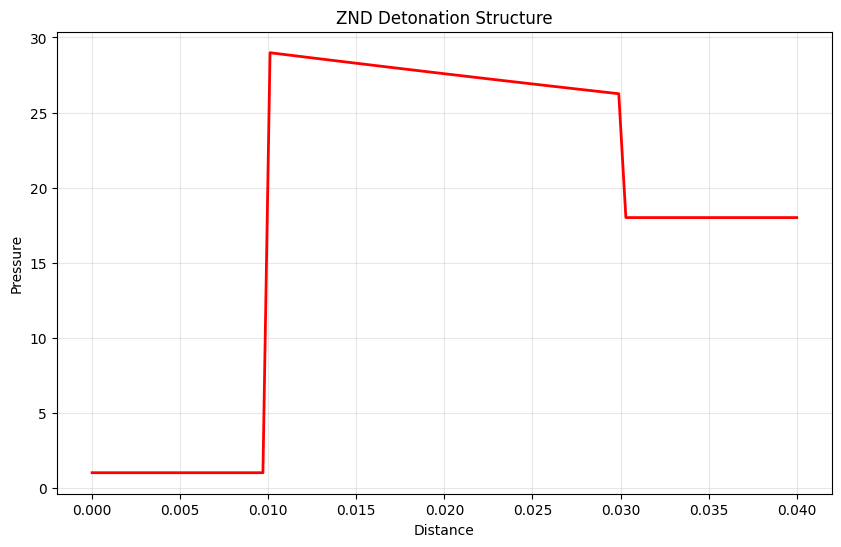

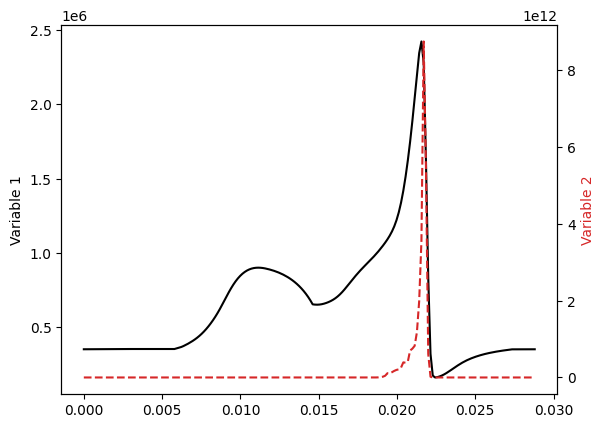

In [11]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

prim = np.load(r'C:\GIT_Fork\ROMify\examples\1D_RDE\FOM_results\5000iteration_prim.npy')
x    = np.linspace(0, 0.0288, 200)

# Left y-axis
ax.plot(x, prim[2, :], c='black', ls='-')
ax.set_ylabel('Variable 1', color='black')

# Right y-axis
ax2 = ax.twinx()
ax2.plot(x, prim[-1, :], c='tab:red', ls='--')
ax2.set_ylabel('Variable 2', color='tab:red')

plt.show()
